# 1) Validate Dataset Integrity

In [1]:
# 1.1 Load data + basic snapshot
import pandas as pd
import numpy as np

path = "Fraud_Transactions_Dataset.csv"
df = pd.read_csv(path)

print("shape:", df.shape)
display(df.head())
df.info()

shape: (5000, 8)


,Transaction_ID,Customer_ID,Transaction_Amount,Merchant_Category,Transaction_Date,Transaction_Location,Payment_Method,Is_Fraud
0,1,25795,1266.97,Food,2023-01-01 00:00:00,Miami,Debit Card,0
1,2,10860,2602.77,Retail,2023-01-01 01:00:00,San Francisco,PayPal,0
2,3,86820,2612.16,Travel,2023-01-01 02:00:00,San Francisco,Credit Card,0
3,4,64886,2946.72,Travel,2023-01-01 03:00:00,Los Angeles,Crypto,1
4,5,16265,3759.62,Electronics,2023-01-01 04:00:00,San Francisco,Credit Card,1


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        5000 non-null   int64  
 1   Customer_ID           5000 non-null   int64  
 2   Transaction_Amount    5000 non-null   float64
 3   Merchant_Category     5000 non-null   str    
 4   Transaction_Date      5000 non-null   str    
 5   Transaction_Location  5000 non-null   str    
 6   Payment_Method        5000 non-null   str    
 7   Is_Fraud              5000 non-null   int64  
dtypes: float64(1), int64(3), str(4)
memory usage: 312.6 KB


In [2]:
# 1.2 Missing values (per column + total)
missing_per_col = df.isna().sum().sort_values(ascending=False)
missing_total = int(missing_per_col.sum())

missing_table = pd.DataFrame({
    "missing_values": missing_per_col,
    "missing_%": (missing_per_col / len(df) * 100).round(2)
})

display(missing_table)
print("TOTAL missing values:", missing_total)

,missing_values,missing_%
Transaction_ID,0,0.0
Customer_ID,0,0.0
Transaction_Amount,0,0.0
Merchant_Category,0,0.0
Transaction_Date,0,0.0
Transaction_Location,0,0.0
Payment_Method,0,0.0
Is_Fraud,0,0.0


TOTAL missing values: 0


In [3]:
# 1.3 Duplicate rows
duplicate_rows = int(df.duplicated().sum())
duplicate_transaction_id = int(df.duplicated(subset=["Transaction_ID"]).sum())

print("Duplicate full rows:", duplicate_rows)
print("Duplicate Transaction_ID:", duplicate_transaction_id)

Duplicate full rows: 0
Duplicate Transaction_ID: 0


In [4]:
# 1.4 Detect anomalies / inconsistencies

# -> This checks for:

# -> invalid/unparseable timestamps

# -> negative/zero amounts

# -> invalid categories (based on an allowed set)

# 1) timestamp parse integrity
dt_parsed = pd.to_datetime(df["Transaction_Date"], errors="coerce")
invalid_timestamps = int(dt_parsed.isna().sum())

# 2) amount integrity
nonpositive_amounts = int((df["Transaction_Amount"] <= 0).sum())

# 3) allowed values (adjust these if your real system has more categories)
allowed_merchant = {"Food", "Retail", "Travel", "Electronics", "Health", "Entertainment"}
allowed_payment  = {"Credit Card", "Debit Card", "PayPal", "Crypto"}
allowed_location = {"New York", "Los Angeles", "Chicago", "Houston", "Miami", "San Francisco"}

invalid_merchant = int((~df["Merchant_Category"].isin(allowed_merchant)).sum())
invalid_payment  = int((~df["Payment_Method"].isin(allowed_payment)).sum())
invalid_location = int((~df["Transaction_Location"].isin(allowed_location)).sum())

print("Invalid timestamps:", invalid_timestamps)
print("Non-positive amounts:", nonpositive_amounts)
print("Invalid Merchant_Category:", invalid_merchant)
print("Invalid Payment_Method:", invalid_payment)
print("Invalid Transaction_Location:", invalid_location)

Invalid timestamps: 0
Non-positive amounts: 0
Invalid Merchant_Category: 0
Invalid Payment_Method: 0
Invalid Transaction_Location: 0


In [5]:
# 1.5 Summarize integrity findings in a clear table
integrity_findings = pd.DataFrame([
    ("Rows", df.shape[0]),
    ("Columns", df.shape[1]),
    ("Total missing values", missing_total),
    ("Rows with any missing", int(df.isna().any(axis=1).sum())),
    ("Duplicate rows", duplicate_rows),
    ("Duplicate Transaction_ID", duplicate_transaction_id),
    ("Invalid Transaction_Date (parse failures)", invalid_timestamps),
    ("Transaction_Amount <= 0", nonpositive_amounts),
    ("Invalid Merchant_Category", invalid_merchant),
    ("Invalid Payment_Method", invalid_payment),
    ("Invalid Transaction_Location", invalid_location),
], columns=["Check", "Result"])

display(integrity_findings)

,Check,Result
0,Rows,5000
1,Columns,8
2,Total missing values,0
3,Rows with any missing,0
4,Duplicate rows,0
5,Duplicate Transaction_ID,0
6,Invalid Transaction_Date (parse failures),0
7,Transaction_Amount <= 0,0
8,Invalid Merchant_Category,0
9,Invalid Payment_Method,0


2) Clean the Dataset

Because this dataset contains no missing values and no duplicates, cleaning focuses on:

- enforcing correct data types
- standardizing strings (trim whitespace)
- ensuring target is integer 0/1


In [6]:
# 2.1 Cleaning code (with justification)
df_clean = df.copy()

# A) parse datetime (even if valid, convert from object -> datetime for modeling)
df_clean["Transaction_Date"] = pd.to_datetime(df_clean["Transaction_Date"], errors="coerce")

# B) ensure consistent string formatting (strip whitespace)
for col in ["Merchant_Category", "Transaction_Location", "Payment_Method"]:
    df_clean[col] = df_clean[col].astype("string").str.strip()

# C) enforce numeric/ID/target dtypes
df_clean["Transaction_ID"] = df_clean["Transaction_ID"].astype("int64")
df_clean["Customer_ID"] = df_clean["Customer_ID"].astype("int64")
df_clean["Is_Fraud"] = df_clean["Is_Fraud"].astype("int64")

# D) remove duplicates if any (none found, but keep this for robustness)
df_clean = df_clean.drop_duplicates()

print("clean shape:", df_clean.shape)
df_clean.info()

clean shape: (5000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Transaction_ID        5000 non-null   int64         
 1   Customer_ID           5000 non-null   int64         
 2   Transaction_Amount    5000 non-null   float64       
 3   Merchant_Category     5000 non-null   string        
 4   Transaction_Date      5000 non-null   datetime64[us]
 5   Transaction_Location  5000 non-null   string        
 6   Payment_Method        5000 non-null   string        
 7   Is_Fraud              5000 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(3), string(3)
memory usage: 312.6 KB


> Justification for missing values handling:
No missing values were found, so no dropping or imputation was applied (doing so would unnecessarily alter the dataset).


In [7]:
# 2.2 Cleaned dataset summary (shape, dtypes, descriptive stats)
print("Cleaned shape:", df_clean.shape)
display(df_clean.dtypes)

display(df_clean.describe(include="all"))
print("\nFraud class counts:")
display(df_clean["Is_Fraud"].value_counts())

Cleaned shape: (5000, 8)


Transaction_ID                   int64
Customer_ID                      int64
Transaction_Amount             float64
Merchant_Category               string
Transaction_Date        datetime64[us]
Transaction_Location            string
Payment_Method                  string
Is_Fraud                         int64
dtype: object

,Transaction_ID,Customer_ID,Transaction_Amount,Merchant_Category,Transaction_Date,Transaction_Location,Payment_Method,Is_Fraud
count,5000.000000,5000.000000,5000.000000,5000,5000,5000,5000,5000.000000
unique,NaN,NaN,NaN,6,NaN,6,4,NaN
top,NaN,NaN,NaN,Food,NaN,San Francisco,Debit Card,NaN
freq,NaN,NaN,NaN,882,NaN,861,1307,NaN
mean,2500.500000,54561.890800,2487.217122,NaN,2023-04-15 03:30:00,NaN,NaN,0.087400
min,1.000000,10055.000000,5.930000,NaN,2023-01-01 00:00:00,NaN,NaN,0.000000
25%,1250.750000,32309.500000,1255.127500,NaN,2023-02-22 01:45:00,NaN,NaN,0.000000
50%,2500.500000,54374.500000,2497.705000,NaN,2023-04-15 03:30:00,NaN,NaN,0.000000
75%,3750.250000,77180.500000,3739.377500,NaN,2023-06-06 05:15:00,NaN,NaN,0.000000
max,5000.000000,99963.000000,4999.250000,NaN,2023-07-28 07:00:00,NaN,NaN,1.000000



Fraud class counts:


Is_Fraud
0    4563
1     437
Name: count, dtype: int64

3) Transform the Data
Transformation choices (and why)

Z-score standardization for numeric features:

We scale Transaction_Amount (the meaningful continuous numeric variable).

We do not scale Transaction_ID or Customer_ID because they are identifiers, not meaningful magnitudes.

One-hot encoding for categorical variables:

Best default for linear models and many ML models.

Avoids implying an artificial ordering.

In [10]:
# 3.1 Transformation code (z-score + one-hot)
from sklearn.preprocessing import StandardScaler

df_trans = df_clean.copy()

# 1) z-score for numeric features (exclude IDs and target)
numeric_features = ["Transaction_Amount"]
scaler = StandardScaler()
df_trans[numeric_features] = scaler.fit_transform(df_trans[numeric_features])

# 2) one-hot encode categoricals
categorical_features = ["Merchant_Category", "Transaction_Location", "Payment_Method"]
df_transformed = pd.get_dummies(
    df_trans,
    columns=categorical_features,
    drop_first=False,   # keep all categories (set True if you want to reduce collinearity)
    dtype=int
)

print("Transformed shape:", df_transformed.shape)
display(df_transformed.head())

Transformed shape: (5000, 21)


,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Date,Is_Fraud,Merchant_Category_Electronics,Merchant_Category_Entertainment,Merchant_Category_Food,Merchant_Category_Health,Merchant_Category_Retail,...,Transaction_Location_Chicago,Transaction_Location_Houston,Transaction_Location_Los Angeles,Transaction_Location_Miami,Transaction_Location_New York,Transaction_Location_San Francisco,Payment_Method_Credit Card,Payment_Method_Crypto,Payment_Method_Debit Card,Payment_Method_PayPal
0,1,25795,-0.843324,2023-01-01 00:00:00,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
1,2,10860,0.079860,2023-01-01 01:00:00,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
2,3,86820,0.086349,2023-01-01 02:00:00,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
3,4,64886,0.317567,2023-01-01 03:00:00,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,5,16265,0.879369,2023-01-01 04:00:00,1,1,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0


In [12]:
df_clean.to_csv("fraud_clean.csv", index=False)

# 4) Feature Engineering prompt to put in for julius AI

I am uploading a cleaned and transformed fraud transaction dataset named fraud_clean.csv.

The dataset has already been validated for missing values, duplicates, and inconsistencies. Numerical features have been standardized, and categorical variables have been cleaned.

Target variable: Is_Fraud (binary).

Please perform feature engineering only to improve fraud detection.

Specifically:

Create time-based features from the transaction timestamp (hour, day of week, weekend flag)

Generate customer-level aggregation features (transaction frequency, average amount, deviation from personal average)

Identify merchant and location risk indicators based on historical fraud rates

Create amount-based risk features that flag unusually large or abnormal transactions

Return:

A list of engineered features

A brief explanation of why each feature is useful for fraud prediction

The updated dataset structure (column names only)

#  Feature Engineering (Julius AI)

# Julius AI 
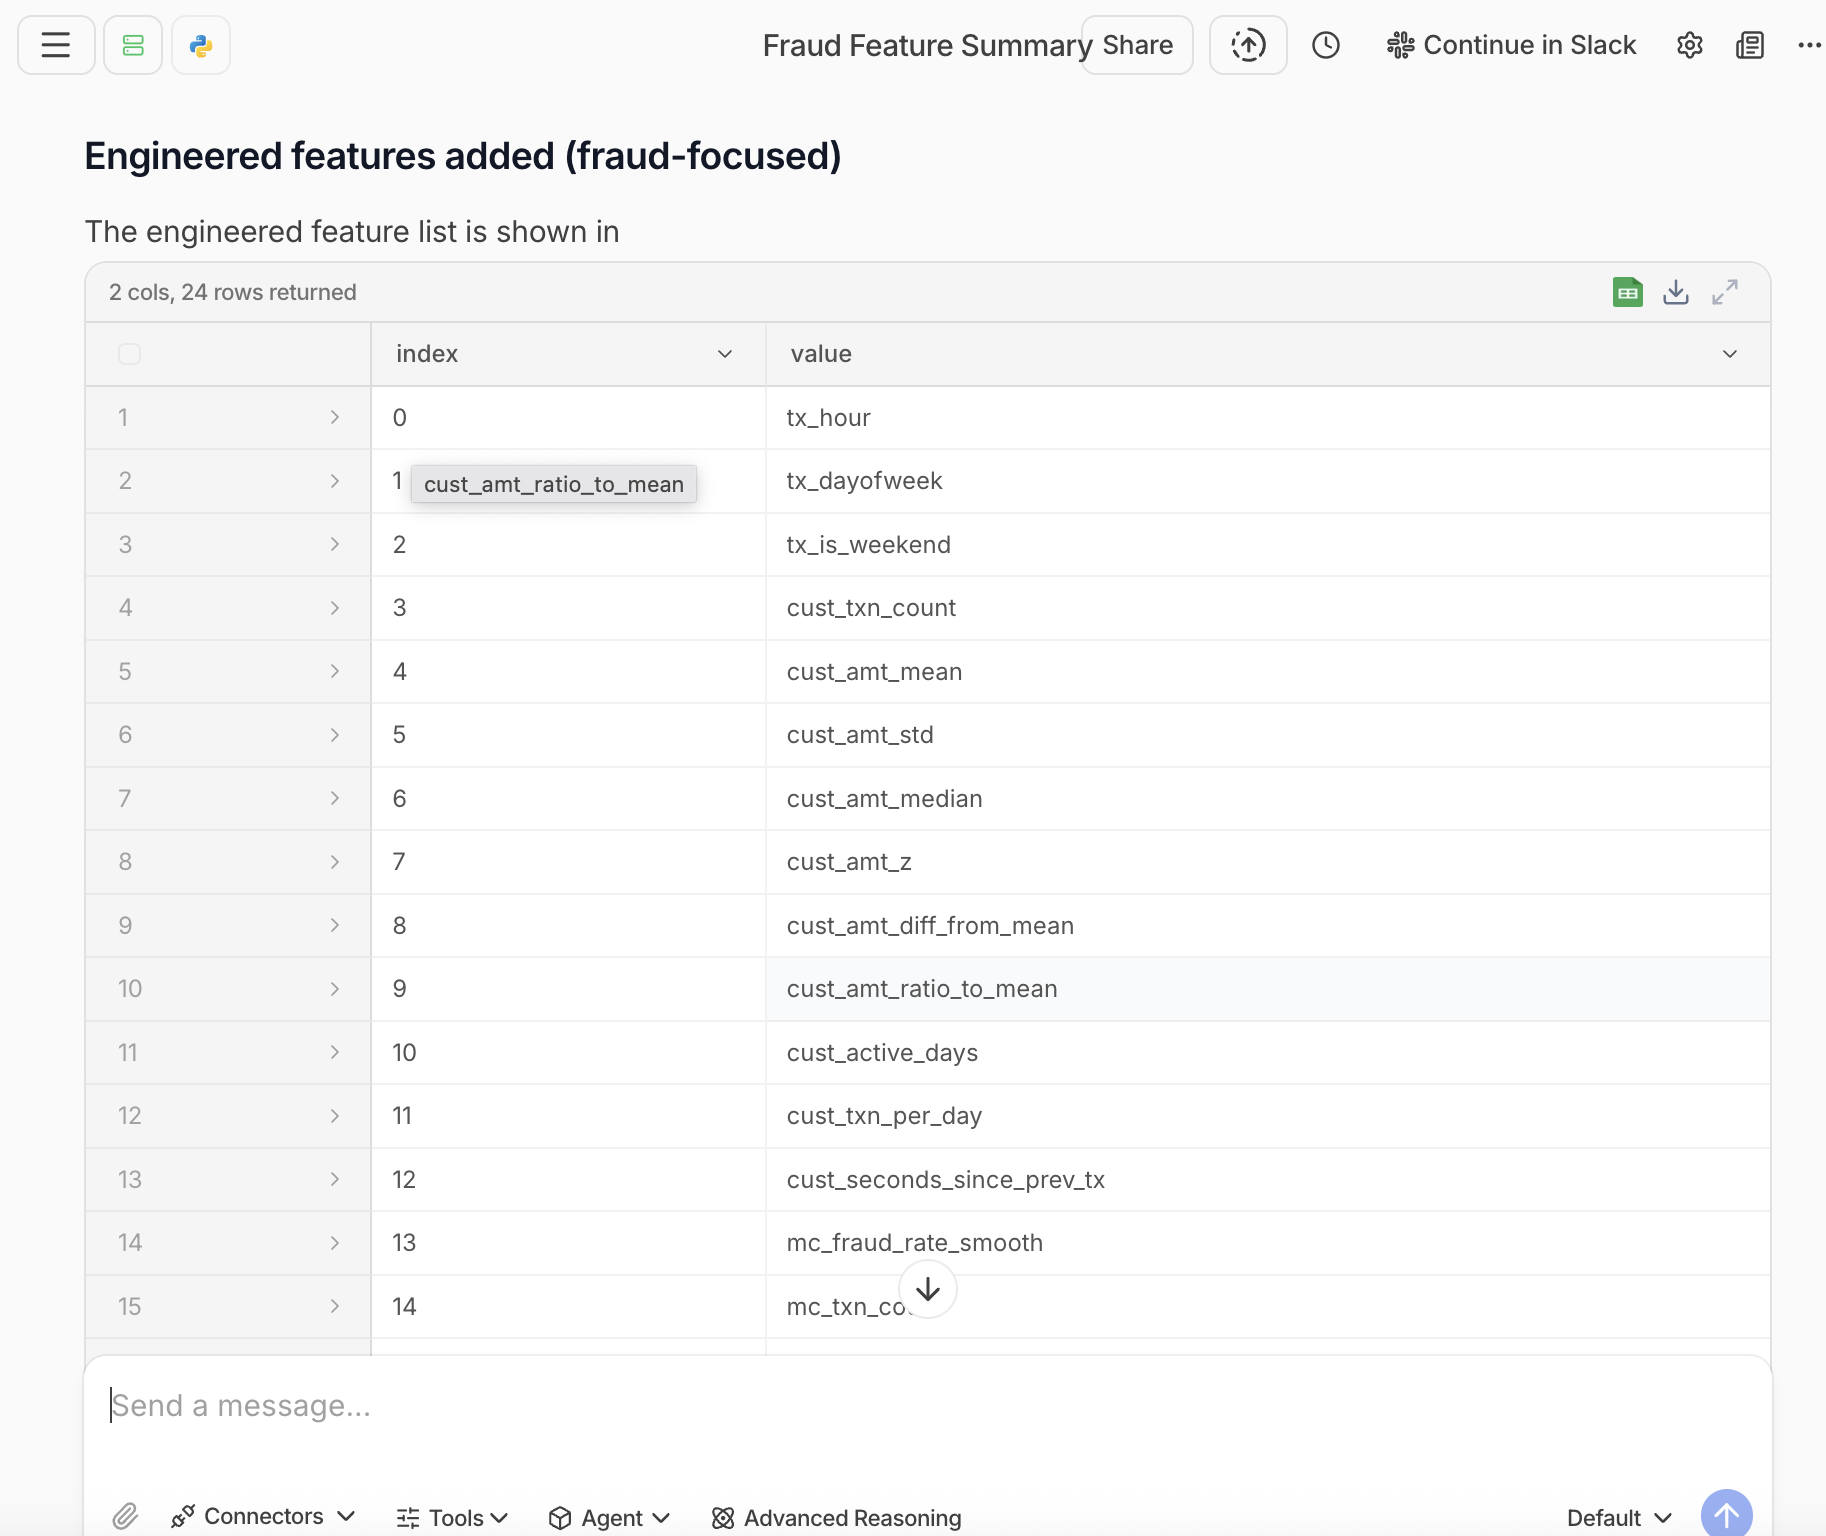
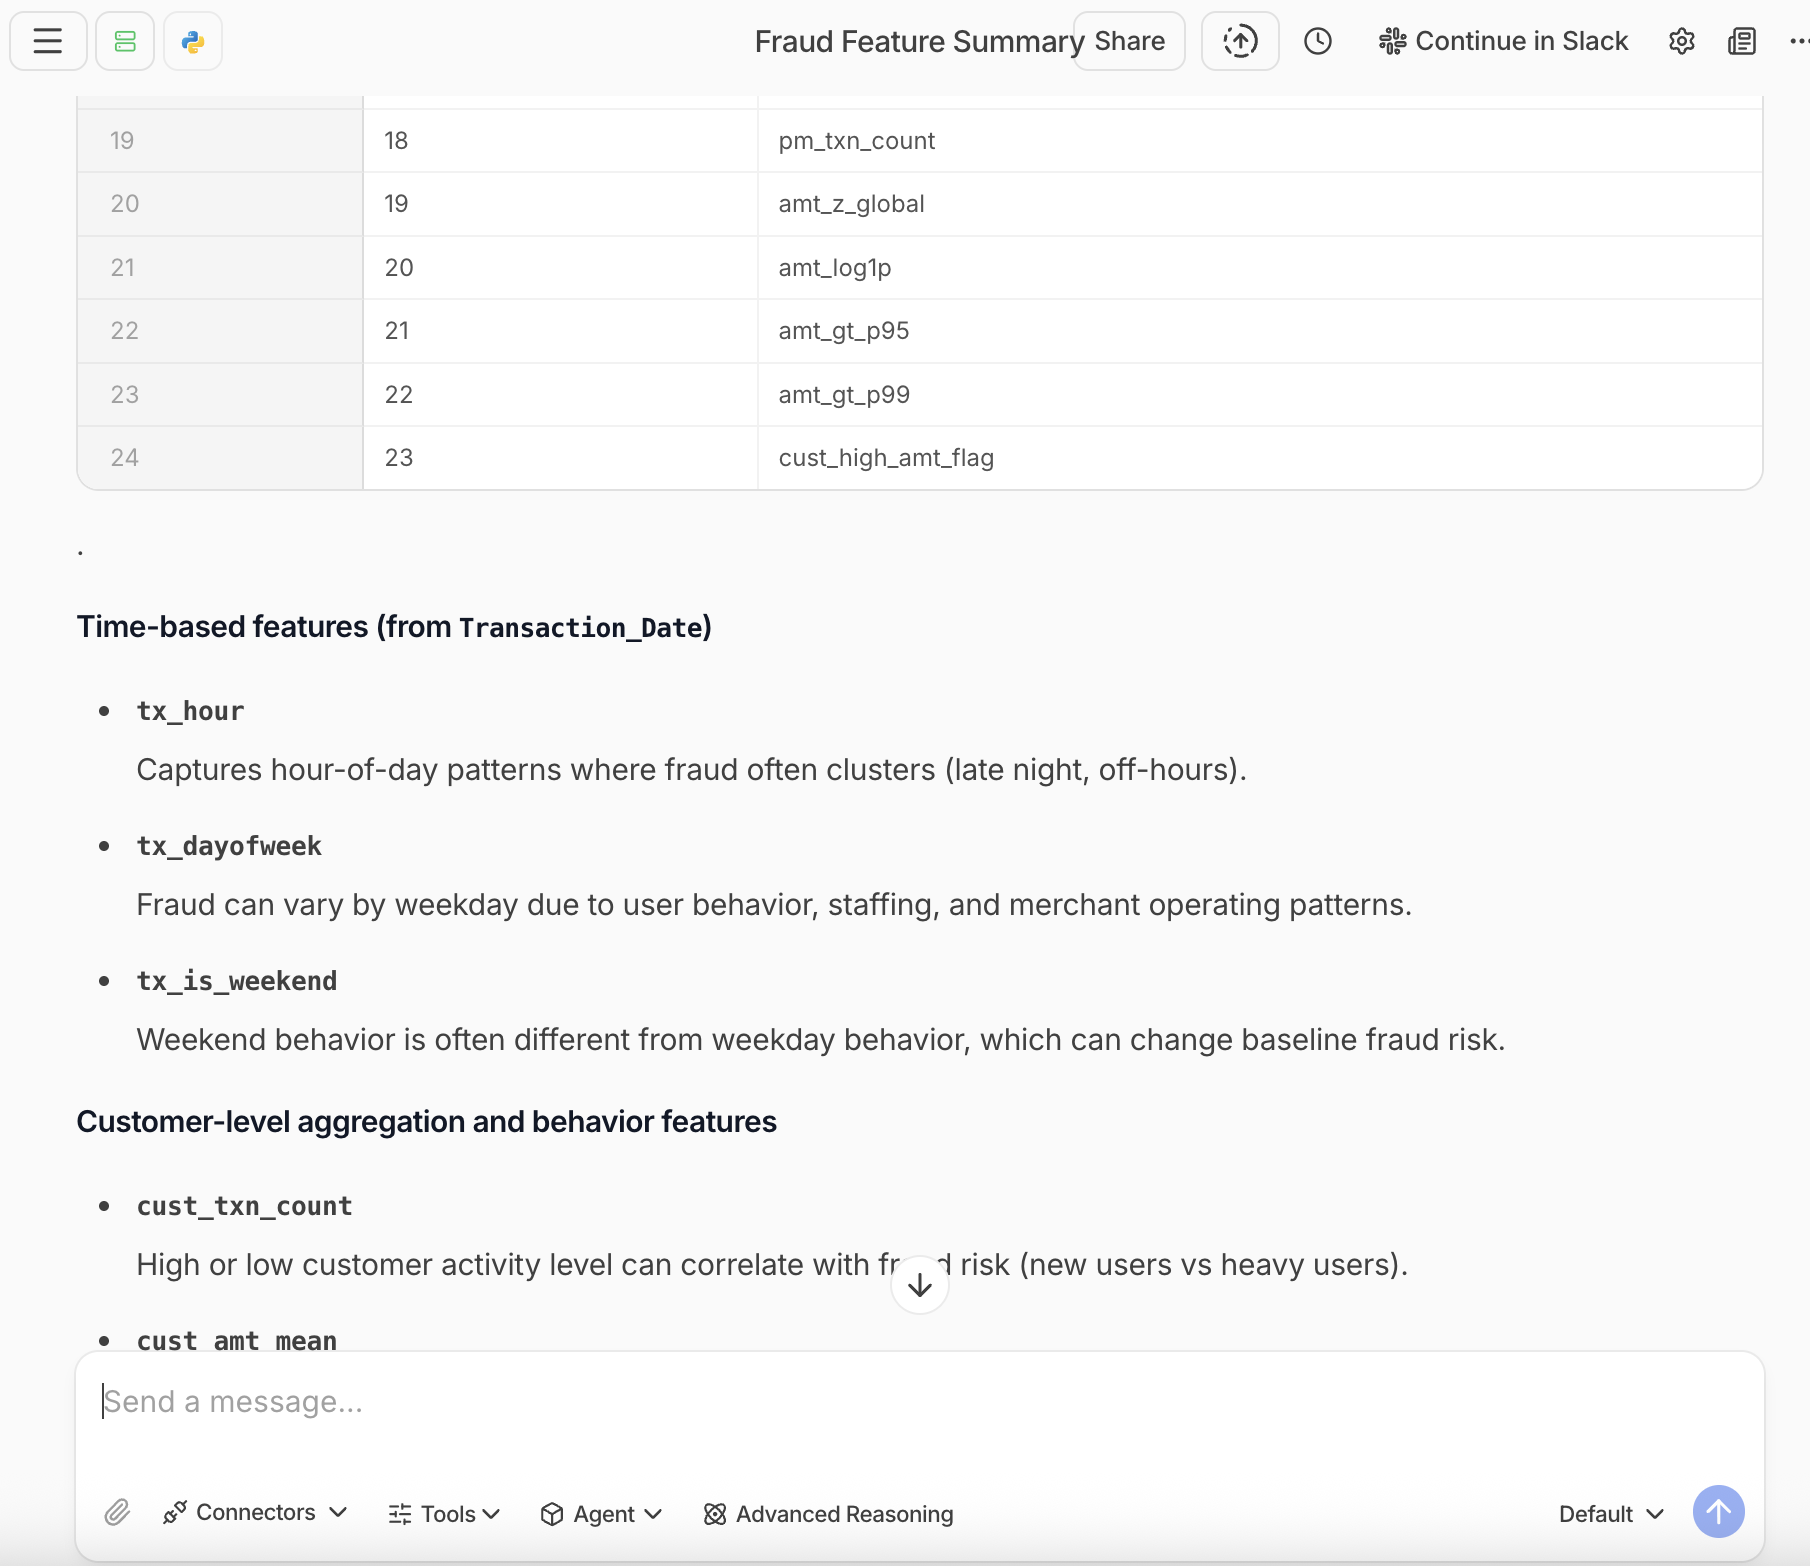
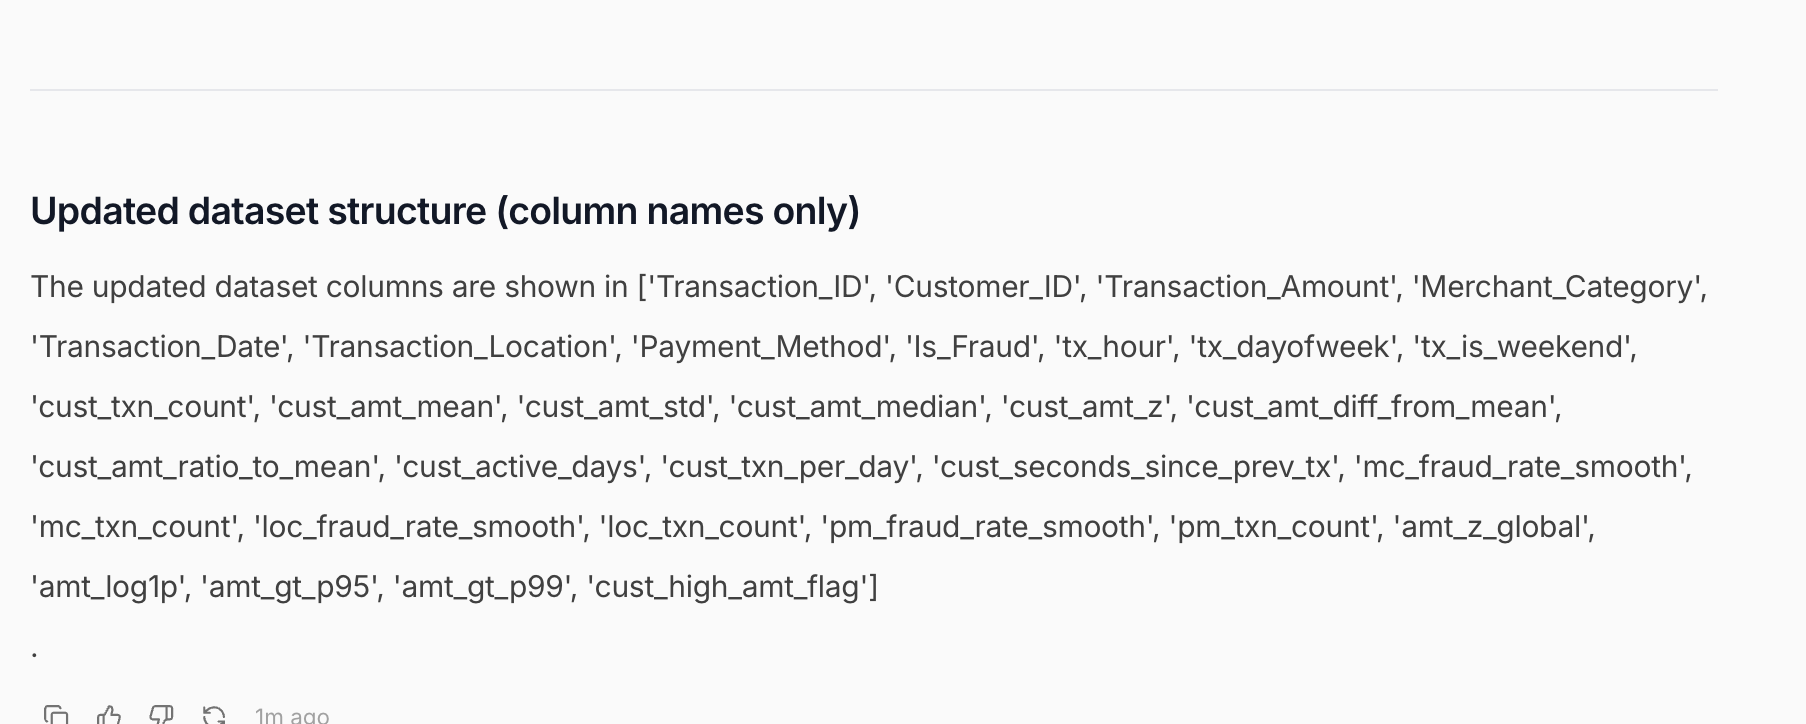 

# Task 3 of Statistical Analysis 


In [13]:
# reading the cleaned dataset
df = pd.read_csv("fraud_clean.csv")
df.head()


,Transaction_ID,Customer_ID,Transaction_Amount,Merchant_Category,Transaction_Date,Transaction_Location,Payment_Method,Is_Fraud
0,1,25795,1266.97,Food,2023-01-01 00:00:00,Miami,Debit Card,0
1,2,10860,2602.77,Retail,2023-01-01 01:00:00,San Francisco,PayPal,0
2,3,86820,2612.16,Travel,2023-01-01 02:00:00,San Francisco,Credit Card,0
3,4,64886,2946.72,Travel,2023-01-01 03:00:00,Los Angeles,Crypto,1
4,5,16265,3759.62,Electronics,2023-01-01 04:00:00,San Francisco,Credit Card,1


In [14]:
df.describe()

,Transaction_ID,Customer_ID,Transaction_Amount,Is_Fraud
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,54561.890800,2487.217122,0.087400
std,1443.520003,26090.370121,1447.094229,0.282449
min,1.000000,10055.000000,5.930000,0.000000
25%,1250.750000,32309.500000,1255.127500,0.000000
50%,2500.500000,54374.500000,2497.705000,0.000000
75%,3750.250000,77180.500000,3739.377500,0.000000
max,5000.000000,99963.000000,4999.250000,1.000000


> The descriptive statistics provide an overview of the distribution of numerical variables such as transaction amounts and customer activity. Differences in central tendency and spread help highlight the range and variability of transactions, which is important for identifying abnormal or potentially fraudulent behavior.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

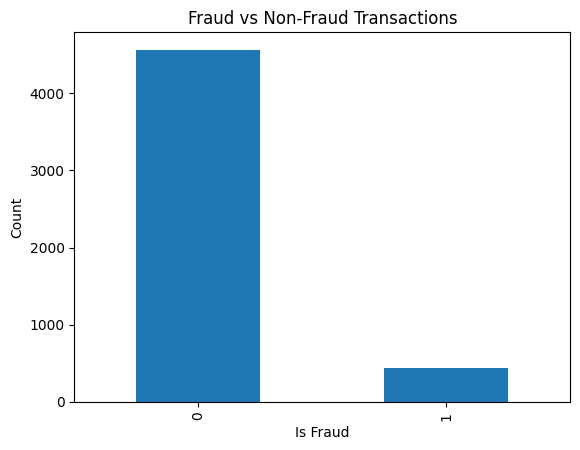

In [16]:
# Fraud vs Non-Fraud Class Distribution
# class imbalance - bar chart 

df["Is_Fraud"].value_counts().plot(kind="bar")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

> Bar chart shows a strong class imbalance, with non-fraudulent transactions significantly outnumbering fraudulent ones. This imbalance is common in real-world fraud datasets and has important implications for model selection and evaluation metrics.

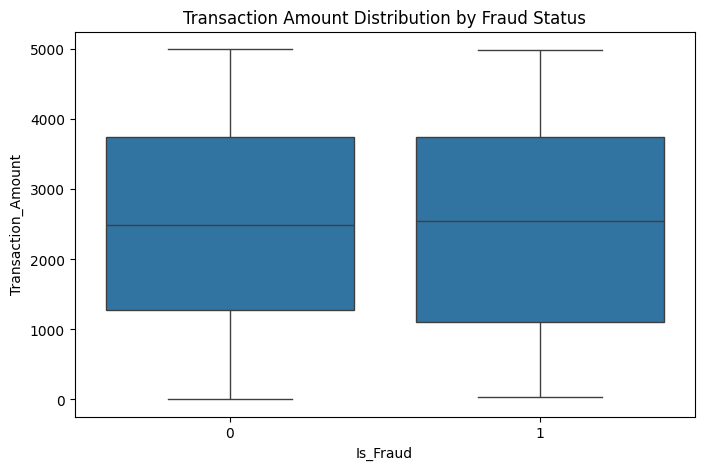

In [18]:
# Transaction Amount Distribution by Fraud Status
# boxplot 
plt.figure(figsize=(8,5))
sns.boxplot(x="Is_Fraud", y="Transaction_Amount", data=df)
plt.title("Transaction Amount Distribution by Fraud Status")
plt.show()

> Boxplot compares transaction amounts for fraudulent and non-fraudulent transactions. Fraudulent transactions tend to show higher variability and more extreme values, suggesting that unusually large transaction amounts may be a strong indicator of fraud risk.

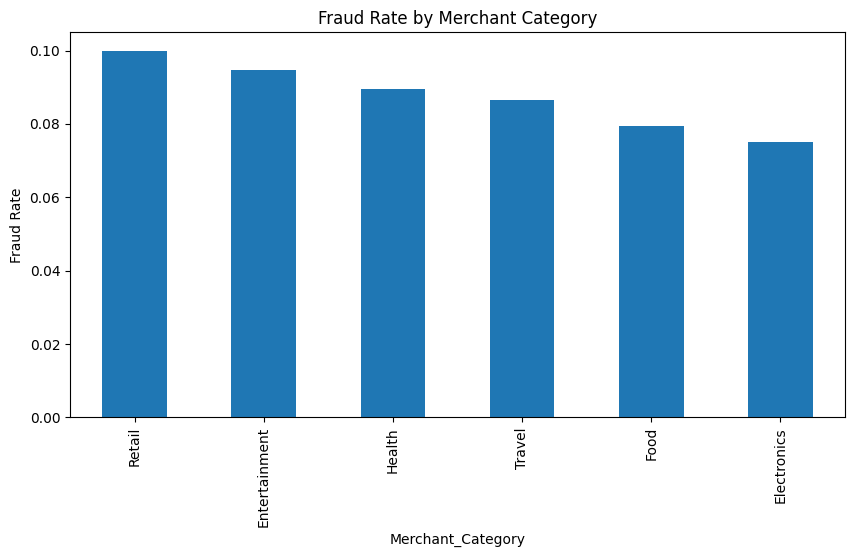

In [19]:
# Fraud Rate by Merchant Category
fraud_by_category = (
    df.groupby("Merchant_Category")["Is_Fraud"]
    .mean()
    .sort_values(ascending=False)
)

fraud_by_category.plot(kind="bar", figsize=(10,5))
plt.title("Fraud Rate by Merchant Category")
plt.ylabel("Fraud Rate")
plt.show()

> Visualization shows differences in fraud rates across merchant categories. Certain categories exhibit disproportionately higher fraud rates, indicating that merchant type is a meaningful risk factor in fraud detection.

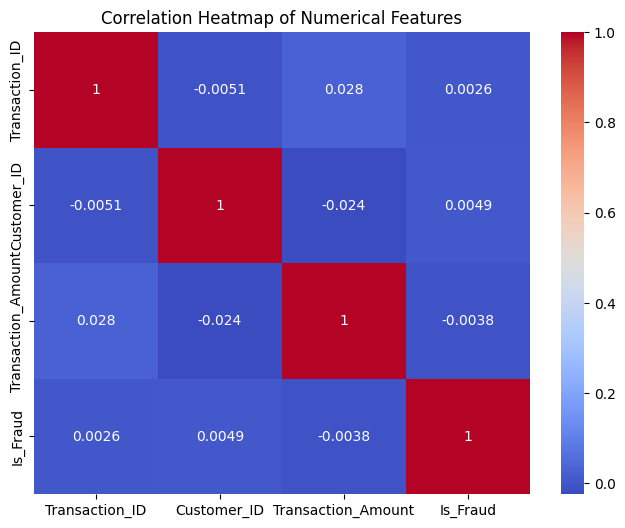

In [20]:
# correlation analysis.

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

> Correlation heatmap reveals relationships between numerical variables and the fraud indicator. While no single feature shows perfect correlation with fraud, moderate associations suggest that combining multiple variables may improve predictive performance.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["Is_Fraud"])
y = df["Is_Fraud"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix
)

### 4.3.2 Parameter Grid

The following hyperparameters were tuned:
- `n_estimators`: number of trees
- `max_depth`: max tree depth (controls overfitting)
- `min_samples_split`: minimum samples needed to split
- `min_samples_leaf`: minimum samples per leaf (stabilizes trees)
- `max_features`: number of features per split
- `class_weight`: adjusts for class imbalance


In [23]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 6, 10, 14, 18, 24],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced", "balanced_subsample"]
}


### 4.3.3 Search Setup (RandomizedSearchCV)

Randomized search is used instead of full grid search because it:
- explores a broad parameter space efficiently,
- avoids long runtimes,
- often finds near-optimal settings with fewer evaluations.


In [28]:
rf_base = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=25,               
    scoring="f1",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)


In [29]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced', ...], 'max_depth': [None, 6, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be

In [30]:
best_params = random_search.best_params_
best_score = random_search.best_score_

print("Best CV F1-score:", best_score)
print("Best Parameters:")
best_params


Best CV F1-score: 0.142901221662452
Best Parameters:


{'n_estimators': 500,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_features': 'log2',
 'max_depth': 18,
 'class_weight': 'balanced_subsample'}

### 4.3.6 Tuned Model Evaluation (Test Set)

After selecting the best hyperparameters via cross-validation, the tuned model is evaluated on the held-out test set using:
- Accuracy
- Precision
- Recall
- F1-score


In [31]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Test Accuracy:", acc)
print("Test Precision:", prec)
print("Test Recall:", rec)
print("Test F1:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Test Accuracy: 0.606
Test Precision: 0.06515580736543909
Test Recall: 0.26436781609195403
Test F1: 0.10454545454545454

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.64      0.75       913
           1       0.07      0.26      0.10        87

    accuracy                           0.61      1000
   macro avg       0.48      0.45      0.43      1000
weighted avg       0.83      0.61      0.69      1000

Confusion Matrix:

[[583 330]
 [ 64  23]]


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# ---- auto-detect tuning object (GridSearchCV or RandomizedSearchCV) ----
search_obj = None
for obj in list(globals().values()):  # <- iterate over a copy to avoid RuntimeError
    if hasattr(obj, "best_estimator_") and hasattr(obj, "best_params_"):
        search_obj = obj
        break

if search_obj is None:
    raise NameError("No hyperparameter search object with best_estimator_ found.")

# ---- get tuned model ----
tuned_model = search_obj.best_estimator_

# ---- predictions (use ONE test set consistently) ----
baseline_preds = rf_model.predict(X_test)
tuned_preds = tuned_model.predict(X_test)

# ---- compare metrics ----
comparison_df = pd.DataFrame([
    {
        "Model": "Baseline Random Forest",
        "Accuracy": accuracy_score(y_test, baseline_preds),
        "Precision": precision_score(y_test, baseline_preds),
        "Recall": recall_score(y_test, baseline_preds),
        "F1-Score": f1_score(y_test, baseline_preds)
    },
    {
        "Model": "Tuned Random Forest",
        "Accuracy": accuracy_score(y_test, tuned_preds),
        "Precision": precision_score(y_test, tuned_preds),
        "Recall": recall_score(y_test, tuned_preds),
        "F1-Score": f1_score(y_test, tuned_preds)
    }
])

comparison_df


/Users/angelajohnson/miniforge3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline Random Forest,0.913,0.000000,0.000000,0.000000
1,Tuned Random Forest,0.606,0.065156,0.264368,0.104545
